In [1]:
#Librerías
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [3]:
#Constantes Físicas
h = 6.62607015e-34 #Constante de Planck (J·s)
c = 2.99792458e8 #Velocidad de la luz (m/s)
k_B = 1.380649e-23 #Constante de Boltzmann (J/K)

In [5]:
#Funciones
def Lambda0_Dom(z, lambda_instrument_data):
    '''
    Esta función crea el dominio de longitud de onda sin redshift para el espectro, es decir, 
    el que se mediría si la funte de radiación no se moviera respecto a nosotros.
    ---
    Argumentos:
    z: Redshift del espectro a generar.
    lambda_instrument_data: Dominio de valores de longitud de onda en los que mide un mismo
                            instrumento.
    '''
    return lambda_instrument_data/(1+z)

def blackbody(lambda0_data, T):
    '''
    Esta función retorna los datos de radiancia de un cuerpo negro a temperatura T para las
    longitudes de onda consideradas.
    ---
    Argumentos:
    lambda0_data: Dominio de valores de longitud de onda emitidos por la fuente.
    T: Temperatura del cuerpo negro.
    '''
    return ((2*h*c**2)/(lambda0_data**5)) / (np.exp((h*c)/(lambda0_data*k_B*T))-1)

def H_lines(lambda0_data, Blackbody_data):
    '''
    Esta función agrega las principales líneas de absorción del hidrógeno a un espectro de
    cuerpo negro.
    ---
    Argumentos:
    lambda0_data: Dominio de valores de longitud de onda emitidos por la fuente.
    Blackbody_data: Datos de radiancia de cuerpo negro emitida por la fuente.
    '''
    depth = 0.7 #profundidad de la línea de absorción (valores entre 0 y 1)
    gamma = 1e-9 #grosor de la línea de absorción
    H_alpha = depth*gamma**2 / ((lambda0_data - 656.21e-9  )**2 + gamma**2)
    H_beta = depth*gamma**2 / ((lambda0_data - 486.08e-9  )**2 + gamma**2)
    H_gamma = depth*gamma**2 / ((lambda0_data - 434.00e-9  )**2 + gamma**2)
    H_delta = depth*gamma**2 / ((lambda0_data - 410.13e-9  )**2 + gamma**2)
    lorentzian_profile = H_alpha + H_beta + H_gamma + H_delta
    return Blackbody_data * (1 - lorentzian_profile)

def noise_generator(emission_data):
    '''
    Esta función agrega ruido gaussiano a un espectro.
    ---
    Argumentos:
    emission_data: Datos de radiancia emitida por la fuente (cuerpo negro + líneas).
    '''
    standar_dev = 10**13 #Qué tanto se desvía el ruido de los datos
    return emission_data + np.random.normal(0, standar_dev, len(emission_data))

def spectrum_generator(T, z, lambda_instrument_data):
    '''
    Esta función genera un espectro sintético de una fuente a temperatura T y con redshift
    z. El espectro corresponde al de un cuerpo negro al cual se le adicionan las cuatro primeras
    líneas de absorción del Hidrógeno y un ruido gaussiano. Este espectro está limitado al 
    dominio de longitudes de onda que puede medir un mismo instrumento.
    ---
    Argumentos:
    T: Temperatura de la fuente.
    z: Redshift de la fuente.
    lambda_instrument_data: Dominio de valores de longitud de onda en los que mide un mismo
                            instrumento.
    '''
    lambda0_data = Lambda0_Dom(z, lambda_instrument_data)
    emission_data = H_lines(lambda0_data, blackbody(lambda0_data ,T))
    spectrum = noise_generator(emission_data)
    return z, spectrum

In [7]:
#Dominio de longitud de onda
lambda_min_measured = 400 #valor mínimo de longitud de onda que mide el instrumento
lambda_max_measured = 900 #valor máximo de longitud de onda que mide el instrumento
N_lambda = 1000 #Número de datos de longitud de onda (relacionado con la nominal del instrumento)
lambda_instrument_data = np.linspace(lambda_min_measured, lambda_max_measured, N_lambda) * 1e-9

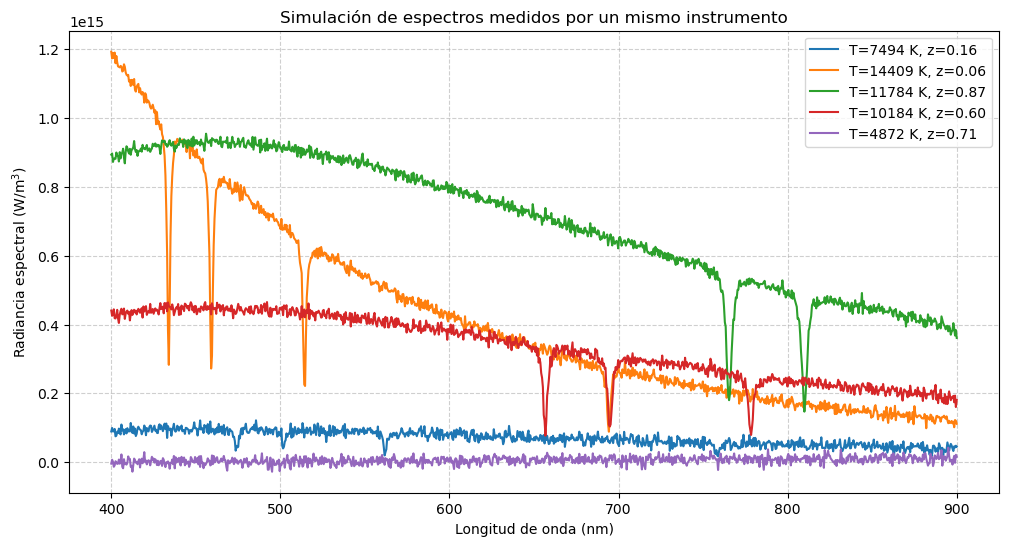

In [5]:
#Prueba

#Número de espectros a generar
N_spectra0 = 5

#Rango de parámetros aleatorios para T y z
np.random.seed(42) #para reproducir
T_values0 = np.random.uniform(3000, 15000, N_spectra0)
z_values0 = np.random.uniform(0, 1, N_spectra0)

#Gráfica
plt.figure(figsize=(12, 6))
for i in range(N_spectra0):
    B = spectrum_generator(T_values0[i], z_values0[i], lambda_instrument_data)[1]
    plt.plot(lambda_instrument_data* 1e9, B, label=f'T={T_values0[i]:.0f} K, z={z_values0[i]:.2f}')
plt.title(f'Simulación de espectros medidos por un mismo instrumento')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Radiancia espectral (W/m$^3$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [9]:
#PRUEBA
#Generación de 5 datos
N_spectra = 5

np.random.seed(42) #para reproducir
T_values = np.random.uniform(3000, 15000, N_spectra)
z_values = np.random.uniform(0, 1, N_spectra)

spectra_data = np.zeros((N_spectra+1, N_lambda+1))
spectra_data[0, 1:] = lambda_instrument_data

for i in range(N_spectra):
    spectra_data[i+1,0], spectra_data[i+1,1:] = spectrum_generator(T_values[i], z_values[i], lambda_instrument_data)

In [11]:
spectra_data

array([[ 0.00000000e+00,  4.00000000e-07,  4.00500501e-07, ...,
         8.98998999e-07,  8.99499499e-07,  9.00000000e-07],
       [ 1.55994520e-01,  8.91567742e+13,  9.93432922e+13, ...,
         4.26807965e+13,  4.76482457e+13,  4.49984685e+13],
       [ 5.80836122e-02,  1.19291346e+15,  1.17385074e+15, ...,
         1.22267372e+14,  1.19926052e+14,  1.11523170e+14],
       [ 8.66176146e-01,  8.93629708e+14,  8.97203003e+14, ...,
         3.67955976e+14,  3.83915689e+14,  3.60975626e+14],
       [ 6.01115012e-01,  4.40608060e+14,  4.25430846e+14, ...,
         1.93396595e+14,  1.60191151e+14,  1.80700667e+14],
       [ 7.08072578e-01, -4.31817201e+12,  6.90322704e+12, ...,
        -1.92011718e+12,  2.13108980e+13,  1.57076664e+13]])

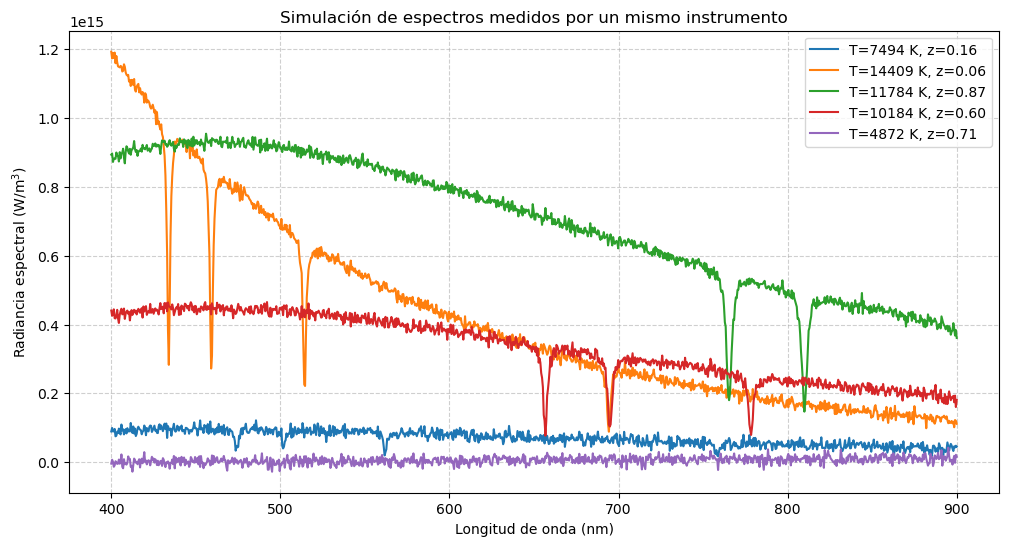

In [13]:
#PRUEBA
#Gráfica
plt.figure(figsize=(12, 6))
for i in range(N_spectra):
    B = spectra_data[i+1, 1:]
    plt.plot(spectra_data[0,1:]* 1e9, B, label=f'T={T_values[i]:.0f} K, z={spectra_data[i+1,0]:.2f}')
plt.title(f'Simulación de espectros medidos por un mismo instrumento')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Radiancia espectral (W/m$^3$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [15]:
#PRUEBA
#Guardar en HDF5
with h5py.File('SpectraData.h5', 'w') as f:
    f.create_dataset('lambda', data=spectra_data[0, 1:])
    f.create_dataset('z', data=z_values)
    f.create_dataset('spectra', data=spectra_data[1:, 1:])
    f.create_dataset('T', data=T_values)
    f.attrs['description'] = 'Espectros sintéticos con líneas H-alpha'

In [17]:
#PRUEBA
#Cargar datos
with h5py.File('SpectraData.h5', 'r') as f:
    lambda_dom_for_NN = f['lambda'][:]
    spectra_for_NN = f['spectra'][:]
    T_for_NN = f['T'][:]
    z_for_NN = f['z'][:]

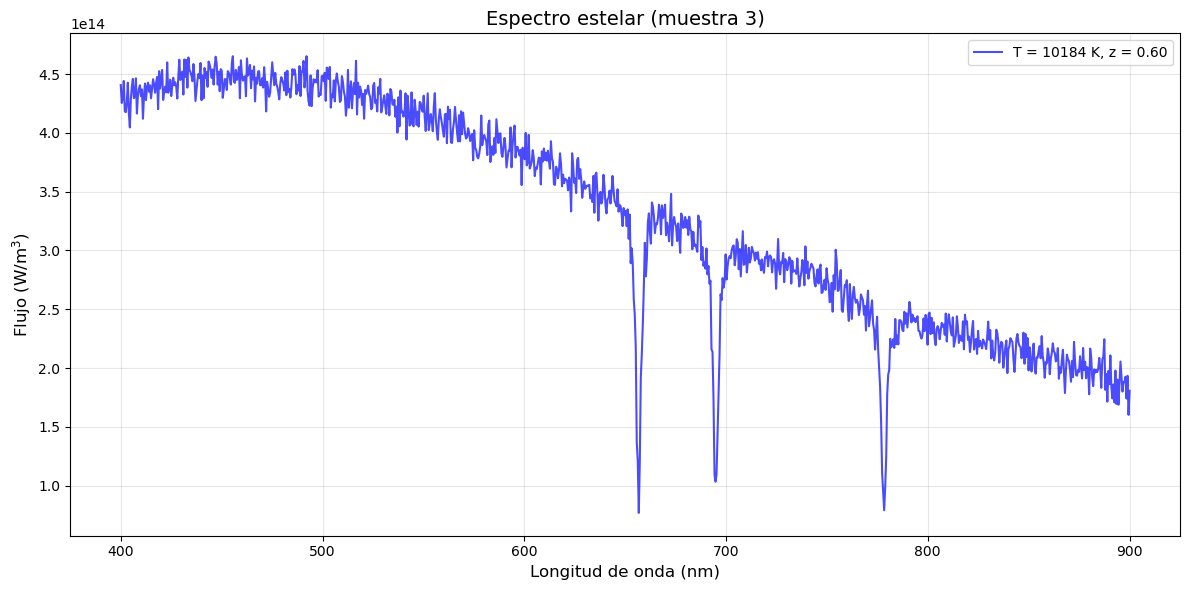

In [21]:
#PRUEBA
#Elegir un espectro aleatorio
idx = np.random.randint(0, len(spectra_for_NN))
spectrum_single = spectra_for_NN[idx]
T_single = T_for_NN[idx]
z_single = z_for_NN[idx]

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(lambda_dom_for_NN * 1e9, spectrum_single, 'b-', alpha=0.7, 
         label=f'T = {T_single:.0f} K, z = {z_single:.2f}')
plt.title(f'Espectro estelar (muestra {idx})', fontsize=14)
plt.xlabel('Longitud de onda (nm)', fontsize=12)
plt.ylabel('Flujo (W/m$^3$)', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
# plt.xlim(600, 1400)  # Rango de interés (H-alpha está en ~656 nm)
plt.tight_layout()
plt.show()